In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

x_train = x_train/255.0
x_test = x_test/255.0

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


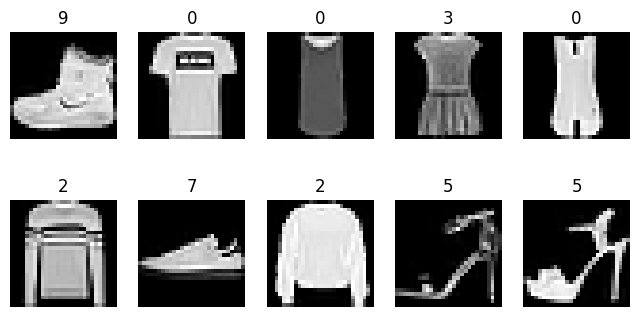

In [3]:
plt.figure(figsize=(8,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

In [4]:
def create_model(filter_size=3, optimizer='adam', reg=None):

    model = keras.Sequential([
        layers.Conv2D(32,(filter_size,filter_size),activation='relu',
                      kernel_regularizer=reg,input_shape=(28,28,1)),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64,(filter_size,filter_size),activation='relu',
                      kernel_regularizer=reg),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),

        layers.Dense(128,activation='relu',
                     kernel_regularizer=reg),

        layers.Dense(10,activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [5]:
class EpochDetails(keras.callbacks.Callback):

    def on_epoch_end(self, epoch, logs=None):

        print("\nEpoch:",epoch+1)

        print("Loss:",logs['loss'])
        print("Accuracy:",logs['accuracy'])

        print("\nLayer Weights Summary:")

        for layer in self.model.layers:

            weights = layer.get_weights()

            if len(weights) > 0:

                w = weights[0]

                print(layer.name,
                      "mean weight:",np.mean(w),
                      "std:",np.std(w))

In [6]:
model = create_model(filter_size=3,
                     optimizer='adam',
                     reg=None)

history = model.fit(
    x_train,y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test,y_test),
    callbacks=[EpochDetails()]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7200 - loss: 0.7845
Epoch: 1
Loss: 0.5448653697967529
Accuracy: 0.803683340549469

Layer Weights Summary:
conv2d mean weight: 0.015195904 std: 0.11303154
conv2d_1 mean weight: 0.0044258526 std: 0.06372525
dense mean weight: 0.0008895673 std: 0.04080557
dense_1 mean weight: -0.012676743 std: 0.13210112
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7202 - loss: 0.7840 - val_accuracy: 0.8580 - val_loss: 0.3939
Epoch 2/10
462/469 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8707 - loss: 0.3626
Epoch: 2
Loss: 0.3501933515071869
Accuracy: 0.874916672706604

Layer Weights Summary:
conv2d mean weight: 0.01015881 std: 0.12632039
conv2d_1 mean weight: 0.0008336163 std: 0.07186036
dense mean weight: 0.00024640534 std: 0.04437527
dense_1 mean weight: -0.014571281 std: 0.1368569
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8707 - loss: 0.3624 - val_accuracy: 0.8755 - val_loss: 0.3470
Epoch 3/10
468/469 ━━━━━━━━━

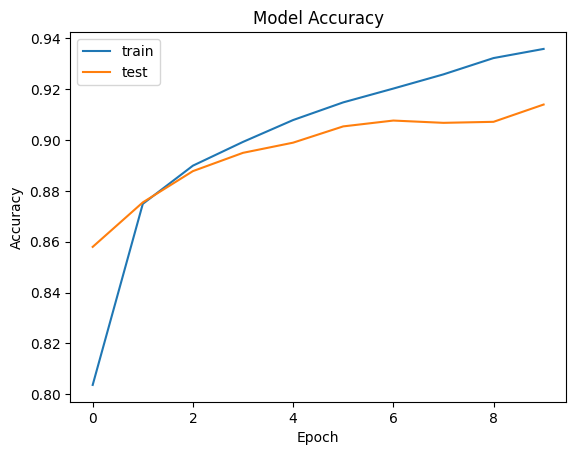

In [8]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['train','test'])
plt.show()

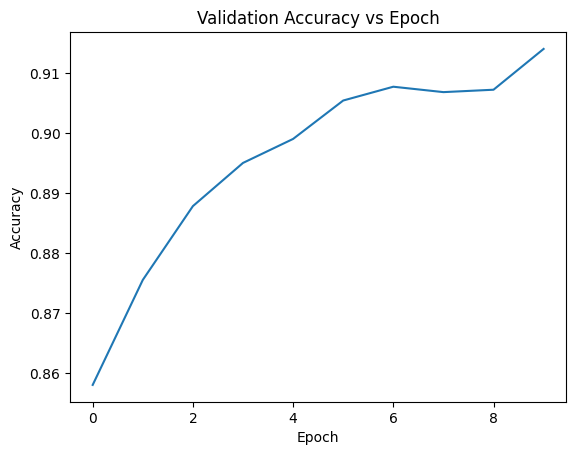

In [19]:
plt.figure()

plt.plot(history.history['val_accuracy'])

plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()

In [7]:
test_loss,test_acc = model.evaluate(x_test,y_test)

print("Test Accuracy:",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9114 - loss: 0.2589
Test Accuracy: 0.9139999747276306


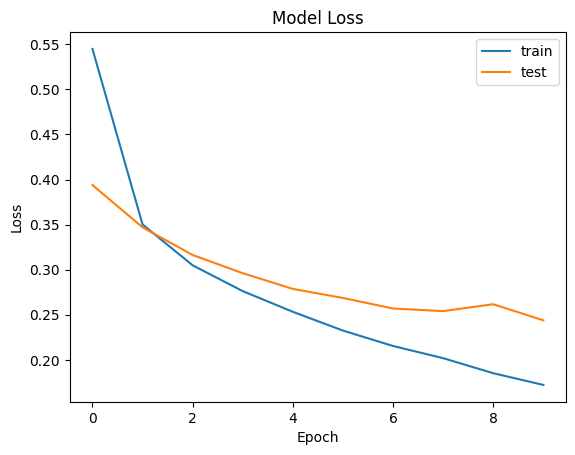

In [9]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['train','test'])
plt.show()

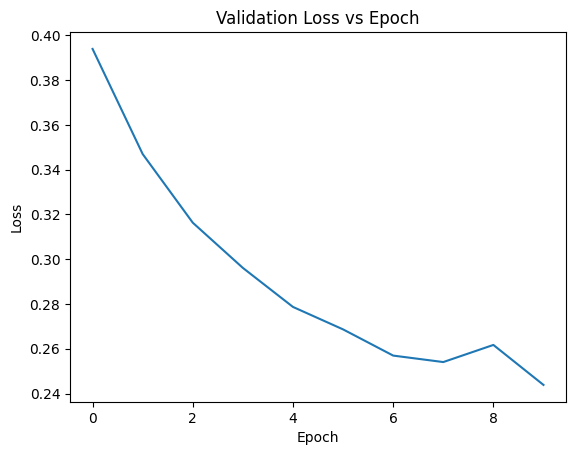

In [20]:
plt.figure()

plt.plot(history.history['val_loss'])

plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()


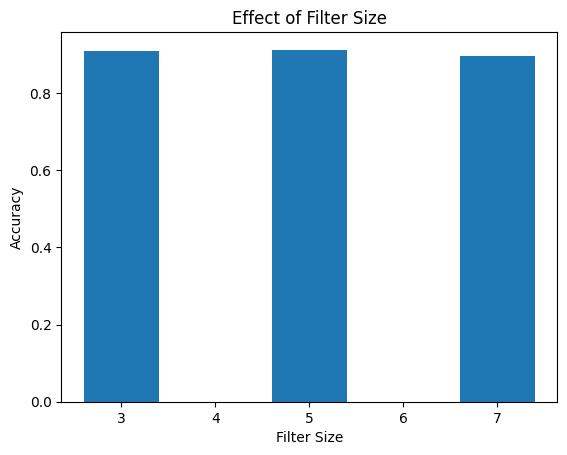

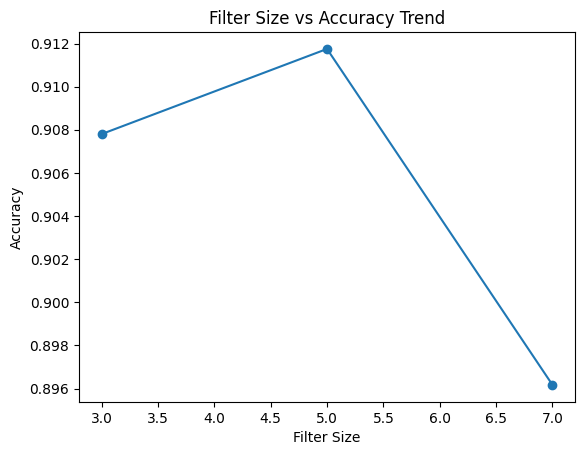

In [24]:
filters = [3,5,7]
results = []
accuracy = results


for f in filters:

    model = create_model(filter_size=f)

    h = model.fit(x_train,y_train,
                  epochs=5,
                  batch_size=128,
                  verbose=0)

    results.append(h.history['accuracy'][-1])

plt.bar(filters,results)

plt.xlabel("Filter Size")
plt.ylabel("Accuracy")
plt.title("Effect of Filter Size")
plt.show()

plt.plot(filters, accuracy, marker='o')

plt.xlabel("Filter Size")
plt.ylabel("Accuracy")
plt.title("Filter Size vs Accuracy Trend")

plt.show()

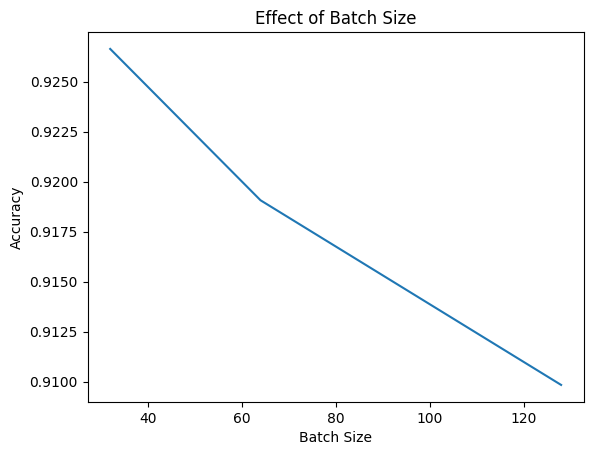

In [11]:
batch_sizes = [32,64,128]
results = []

for b in batch_sizes:

    model = create_model()

    h = model.fit(x_train,y_train,
                  epochs=5,
                  batch_size=b,
                  verbose=0)

    results.append(h.history['accuracy'][-1])

plt.plot(batch_sizes,results)

plt.xlabel("Batch Size")
plt.ylabel("Accuracy")
plt.title("Effect of Batch Size")
plt.show()

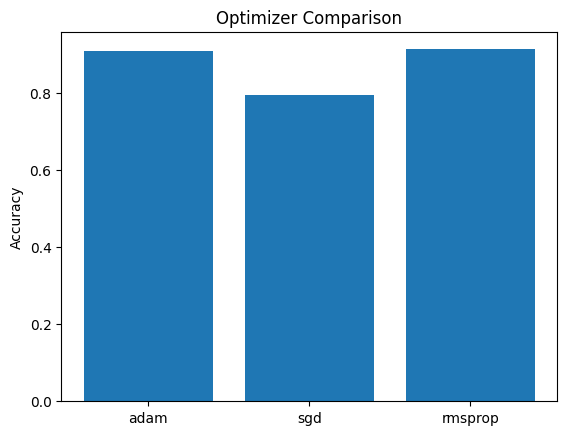

In [14]:
optimizers = ['adam','sgd','rmsprop']
results = []

for opt in optimizers:

    model = create_model(optimizer=opt)

    h = model.fit(x_train,y_train,
                  epochs=5,
                  batch_size=128,
                  verbose=0)

    results.append(h.history['accuracy'][-1])

plt.bar(optimizers,results)

plt.title("Optimizer Comparison")
plt.ylabel("Accuracy")
plt.show()

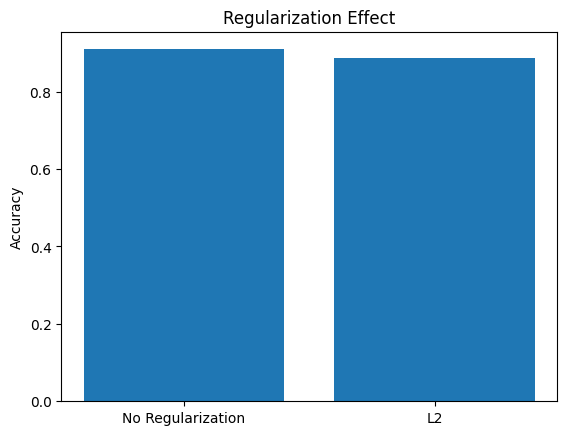

In [15]:
from tensorflow.keras import regularizers

regs = [None,
        regularizers.l2(0.001)]

labels = ['No Regularization','L2']

results = []

for r in regs:

    model = create_model(reg=r)

    h = model.fit(x_train,y_train,
                  epochs=5,
                  batch_size=128,
                  verbose=0)

    results.append(h.history['accuracy'][-1])

plt.bar(labels,results)

plt.title("Regularization Effect")
plt.ylabel("Accuracy")
plt.show()